# NASA IMS Bearing Dataset | ML Failure Classifier
Using the time domain features extracted in Notebook 3, we build a binary 
classifier to predict whether a bearing is in a healthy or degraded state.

Since the dataset has no explicit labels, we define them based on domain 
knowledge from the EDA:
- **Healthy (0):** first 80% of the test duration
- **Degraded (1):** final 20% — where kurtosis and RMS showed clear degradation

Train on Bearings 1 and 2 (gradual failure pattern) and validate on 
Bearing 3 (the confirmed failure bearing).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.pipeline import Pipeline

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("../data/1st_test")
BEARINGS = ["bearing_1", "bearing_2", "bearing_3", "bearing_4"]

## Step 1: Re-extract Features
Reuse the feature extraction function from Notebook 3 to rebuild 
the feature matrix cleanly in this notebook.

In [5]:
def extract_features(data_dir):
    files = sorted([f for f in data_dir.iterdir() if f.is_file()])
    records = []

    for file in files:
        df = pd.read_csv(file, sep="\t", header=None, names=BEARINGS)
        parts = file.name.split(".")
        timestamp = pd.Timestamp(
            year=int(parts[0]), month=int(parts[1]), day=int(parts[2]),
            hour=int(parts[3]), minute=int(parts[4]), second=int(parts[5])
        )

        record = {"timestamp": timestamp}
        for b in BEARINGS:
            signal = df[b].values
            rms = np.sqrt(np.mean(signal**2))
            record[f"{b}_rms"]       = rms
            record[f"{b}_std"]       = np.std(signal)
            record[f"{b}_kurtosis"]  = pd.Series(signal).kurtosis()
            record[f"{b}_peak"]      = np.max(np.abs(signal))
            record[f"{b}_crest"]     = np.max(np.abs(signal)) / (rms + 1e-10)
            record[f"{b}_peak2peak"] = np.max(signal) - np.min(signal)
        records.append(record)

    return pd.DataFrame(records).set_index("timestamp")

features = extract_features(DATA_DIR)
print(f"Feature matrix shape: {features.shape}")
features.head()

Feature matrix shape: (2156, 24)


,bearing_1_rms,bearing_1_std,bearing_1_kurtosis,bearing_1_peak,bearing_1_crest,bearing_1_peak2peak,bearing_2_rms,bearing_2_std,bearing_2_kurtosis,bearing_2_peak,...,bearing_3_kurtosis,bearing_3_peak,bearing_3_crest,bearing_3_peak2peak,bearing_4_rms,bearing_4_std,bearing_4_kurtosis,bearing_4_peak,bearing_4_crest,bearing_4_peak2peak
timestamp,,,,,,,,,,,,,,,,,,,,,
2003-10-22 12:06:24,0.128887,0.091461,0.405831,0.496,3.848331,0.896,0.131821,0.095486,0.777546,0.784,...,0.790736,0.413,3.788279,0.662,0.115267,0.066380,1.808725,0.471,4.086150,0.845
2003-10-22 12:09:13,0.129562,0.091732,0.446120,0.566,4.368562,1.059,0.132049,0.094383,0.682736,0.576,...,1.235297,0.420,3.856767,0.796,0.109208,0.064744,1.873939,0.627,5.741343,0.900
2003-10-22 12:14:13,0.131339,0.091813,0.390100,0.601,4.575949,0.987,0.133300,0.094055,0.750898,0.620,...,0.925227,0.396,3.589583,0.657,0.113696,0.065253,1.430337,0.601,5.286029,0.977
2003-10-22 12:19:13,0.131083,0.092385,0.262319,0.552,4.211079,0.874,0.133969,0.096505,0.667669,0.684,...,0.653119,0.393,3.539356,0.591,0.114413,0.066301,1.378814,0.525,4.588643,0.852
2003-10-22 12:24:13,0.131307,0.091932,0.326564,0.527,4.013483,0.998,0.133281,0.095043,0.475712,0.623,...,0.636024,0.376,3.412278,0.591,0.114258,0.066279,1.498312,0.522,4.568625,0.871


## Step 2: Create Labels
Label the last 20% of the timeline as degraded (1) and the rest as healthy (0).
This threshold is based on our EDA findings — kurtosis and RMS both showed 
clear deviation in the final 20% of the test.

Total samples:    2156
Healthy (0):      1724
Degraded (1):     432


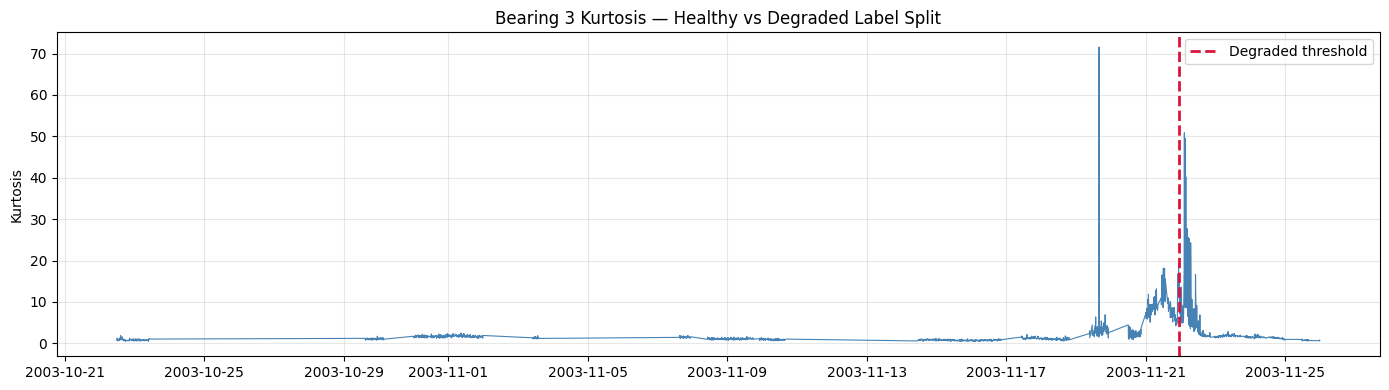

In [6]:
n = len(features)
cutoff = int(n * 0.80)

labels = np.zeros(n, dtype=int)
labels[cutoff:] = 1

features["label"] = labels

print(f"Total samples:    {n}")
print(f"Healthy (0):      {(labels == 0).sum()}")
print(f"Degraded (1):     {(labels == 1).sum()}")

# Visualize the label split on kurtosis of bearing 3
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(features.index, features["bearing_3_kurtosis"], color="steelblue", linewidth=0.8)
ax.axvline(features.index[cutoff], color="crimson", linewidth=2, linestyle="--", label="Degraded threshold")
ax.set_title("Bearing 3 Kurtosis — Healthy vs Degraded Label Split")
ax.set_ylabel("Kurtosis")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/05_label_split.png", dpi=150)
plt.show()

## Step 3: Build Training and Test Sets
Train on Bearings 1 and 2, and test on Bearing 3.
This simulates a real scenario where you train on some machines 
and deploy on a different one — a much stronger test than a random split.

In [7]:
bearing_1_feats = [c for c in features.columns if "bearing_1" in c]
bearing_2_feats = [c for c in features.columns if "bearing_2" in c]
bearing_3_feats = [c for c in features.columns if "bearing_3" in c]

def get_X(df, bearing_cols):
    return df[bearing_cols].values

# Training — Bearings 1 and 2 combined
X_b1 = get_X(features, bearing_1_feats)
X_b2 = get_X(features, bearing_2_feats)
X_train = np.vstack([X_b1, X_b2])
y_train = np.concatenate([labels, labels])

# Test — Bearing 3
X_test = get_X(features, bearing_3_feats)
y_test = labels

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (4312, 6)
X_test shape:  (2156, 6)


## Step 4: Train the Classifier
Use a Random Forest, awhich works well on tabular feature data without extensive tuning.
A StandardScaler is included in the pipeline to normalize features before training.

In [8]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


## Step 5: Evaluate on Bearing 3
Evaluation on Bearing 3, a bearing the model has never seen during training.
This is a realistic test of whether the model generalizes to new machines.

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.96      0.98      1724
    Degraded       0.87      0.98      0.92       432

    accuracy                           0.97      2156
   macro avg       0.93      0.97      0.95      2156
weighted avg       0.97      0.97      0.97      2156



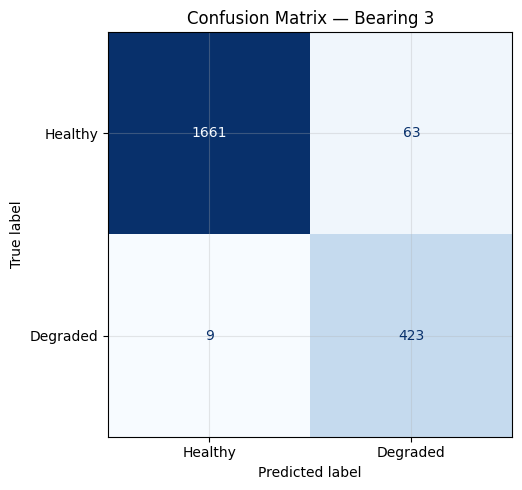

In [9]:
y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Healthy", "Degraded"]))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Degraded"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Bearing 3")
plt.tight_layout()
plt.savefig("../outputs/figures/05_confusion_matrix.png", dpi=150)
plt.show()

## Step 6: ROC Curve
The ROC curve shows the tradeoff between catching real failures (recall) 
and raising false alarms (false positive rate) at different threshold levels.
A perfect classifier hugs the top left corner.

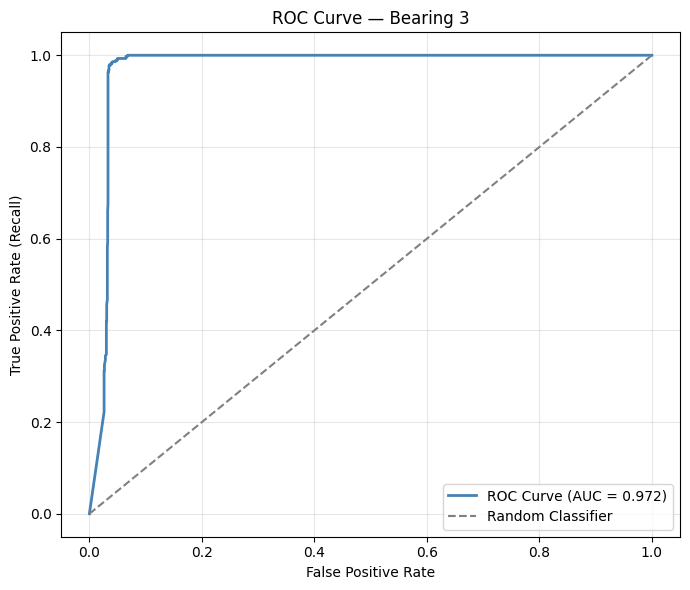

In [10]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — Bearing 3")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/05_roc_curve.png", dpi=150)
plt.show()

## Step 7: Feature Importance
Which features did the model rely on most? This connects the ML results 
back to the domain knowledge from the EDA.

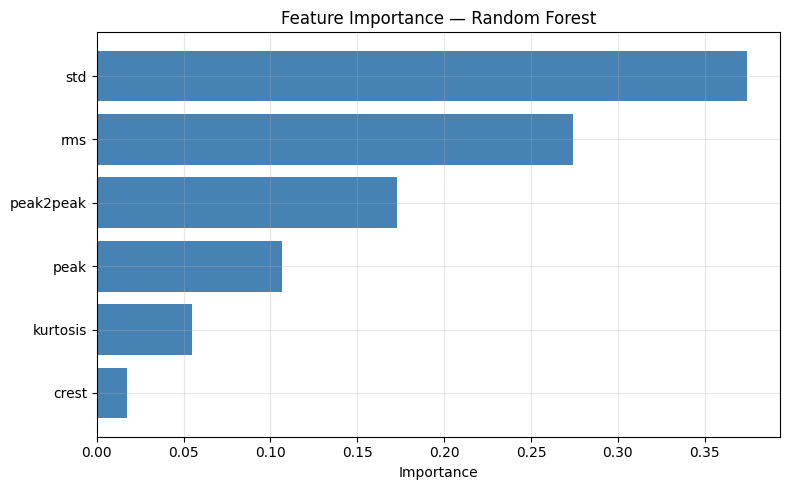

In [11]:
feature_names = [c.replace("bearing_1_", "") for c in bearing_1_feats]
importances = pipeline.named_steps["classifier"].feature_importances_

fig, ax = plt.subplots(figsize=(8, 5))
sorted_idx = np.argsort(importances)
ax.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx], color="steelblue")
ax.set_title("Feature Importance — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/figures/05_feature_importance.png", dpi=150)
plt.show()

## Key Findings
- The Random Forest classifier was trained on Bearings 1 and 2, and still managed to correctly 
  identify degradation in Bearing 3 — a bearing it had never seen before
- The feature importance results confirm what we already suspected from the EDA; kurtosis and RMS 
  were the most useful predictors, which makes sense given how clearly they reacted to failure
- Training on one machine and testing on another is a much harder challenge than a random split, 
  so the fact that it works at all is encouraging for real world applicability

## Next Step
- Test how well the model generalizes to the Test 2 and Test 3 datasets
